# Simulating different telescopes - API code
This notebooks provides examples in how to use the lenstronomy.SimulationAPI modules in simulating (realistic) mock lenses taylored to a specific observation and instrument and makes a montage of different telescope settings currently available.

The module enables to use the astronomical magnitude conventions and can translate those into the lenstronomy core module configurations.

In [16]:
import copy
import os
import numpy as np
import scipy
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


# lenstronomy module import
from lenstronomy.Util import image_util, data_util, util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.SimulationAPI.sim_api import SimAPI
# lenstronomy imports
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.ImSim.image_model import ImageModel
import lenstronomy.Util.param_util as param_util
import lenstronomy.Util.simulation_util as sim_util
import lenstronomy.Util.image_util as image_util
from lenstronomy.Util import kernel_util
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF

import sncosmo
from astropy.table import Table

## SNCOSMO code

In [17]:
z_lens = 0.5
z_source = 0.9
obs = Table({'time': [56176.19, 56188.254, 56207.172],
             'band': ['desg', 'desr', 'desi'],          #filters we are observing in 
             'gain': [1., 1., 1.],                      #dw 
             'skynoise': [0, 0, 0],      #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [30., 30., 30.],                     # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes 
             'zpsys':['ab', 'ab', 'ab']})               # ab magnitudes, units of zero point
# print (obs)

# Will be observing in g and r band
# for now set to highest redshift that it will allow

model = sncosmo.Model(source='salt2')
params = {'z': z_source, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}   #what are the last 3 params

lcs = sncosmo.realize_lcs(obs, model, [params])
print(lcs)
flux_values = np.array(lcs[0]['flux'])
zero_points = np.array(obs['zp'])
magnitudes = zero_points - 2.5 * np.log10(flux_values)

# print(magnitudes)

[<Table length=3>
   time   band        flux             fluxerr          zp   zpsys
 float64  str4      float64            float64       float64  str2
--------- ---- ------------------ ------------------ ------- -----
 56176.19 desg 15.255100295029525   3.74011193048305    30.0    ab
56188.254 desr  622.2834910291764  25.04081427547409    30.0    ab
56207.172 desi  1049.830483697647 31.928604091102482    30.0    ab]


## Define camera and observations
As an example, we define the camera and observational settings of a LSST-like observation. We define one camera setting and three different observations corresponding th g,r,i imaging.

For the complete list of possible settings, we refer to the SimulationAPI.observation_api classes. There are pre-configured settings which approximately mimic observations from current and future instruments. Be careful using those and check whether they are sufficiently accurate for your specific science case!

In [18]:
# Instrument setting from pre-defined configurations

from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST
LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
kwargs_g_band = LSST_g.kwargs_single_band()
LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
kwargs_r_band = LSST_r.kwargs_single_band()
LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
kwargs_i_band = LSST_i.kwargs_single_band()

# lenstronomy provides these setting to be imported with the SimulationAPI.observation_constructor routines.
#Tailored individual settings (as an example) in original API code

## Define model settings

The model settings are handled by the SimulationAPI.model_api ModelAPI class. 
The role is to return instances of the lenstronomy LightModel, LensModel, PointSource modules according to the options chosen by the user. Currently, all other model choices are equivalent to the ones provided by LightModel, LensModel, PointSource.
The current options of the class instance only describe a subset of possibilities and we refer to the specific class instances for details about all the possibilities.

For this example, we chose a single lens plane and a single source plane, elliptical Sersic profiles and an additional lensed point source.

In [19]:
kwargs_model = {'lens_model_list': ['EPL', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                'point_source_model_list': ['SOURCE_POSITION']  # list of point source models to be used
    }

## Generate SimAPI instance for the different observations
Here we make an instanbce of the SimAPI class and execute the major tasks accessible as the interface to the ImSim core module.

In [20]:
numpix = 64  # number of pixels per axis of the image to be modelled

# here we define the numerical options used in the ImSim module. 
# Have a look at the ImageNumerics class for detailed descriptions.
# If not further specified, the default settings are used.
kwargs_numerics = {'point_source_supersampling_factor': 1}

sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model)
sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model)
sim_i = SimAPI(numpix=numpix, kwargs_single_band=kwargs_i_band, kwargs_model=kwargs_model)

# return the ImSim instance. With this class instance, you can compute all the
# modelling accessible of the core modules. See class documentation and other notebooks.
imSim_g = sim_g.image_model_class(kwargs_numerics)
imSim_r = sim_r.image_model_class(kwargs_numerics)
imSim_i = sim_i.image_model_class(kwargs_numerics)

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/lenstronomy/LensModel/lens_model.py:96: UserWarning: Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.
  warnings.warn(


## Brightness definitions in magnitude space
One core feature is the support of light profile amplitudes in astronomical magnitude space (at least for few selected well defined brightness profiles).

We first define all parameters in magnitude space and then use the SimAPI routine to translate the arguments into lenstronomy conventions used by the ImSim module. The second model of each light component we defined as 'INTERPOL', which sets an interpolation grid given an image. This can be used to past real galaxies as lenses or sources into lenstronomy.

In [21]:

# g-band

# lens light - FOREGROUND GALAXY
phi_G, q = 0.5, 0.8
e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
source_x = 0.
source_y = 0.1
kwargs_lens_light_mag_g = [{'magnitude': 15, 'R_sersic': 0.2, 'n_sersic': 1, 
                            'e1': e1, 'e2': e2, 
                            'center_x': source_x, 'center_y': source_y}]

# source light - SN HOST GALAXY
phi_G, q = 0.9, 0.9
e1, e2 = param_util.phi_q2_ellipticity(phi_G, q)
kwargs_source_mag_g = [{'magnitude': 19, 'R_sersic': 0.2, 'n_sersic': 1, 
                        'e1': e1, 'e2': e2, 
                        'center_x': source_x, 'center_y': source_y}]

# point source - SN
kwargs_ps_mag_g = [{'magnitude': 20, 'ra_source': 0.03, 'dec_source': 0}]





# and now we define the colors of the other two bands

# r-band
g_r_source = 1  # color mag_g - mag_r for source
g_r_lens = -1  # color mag_g - mag_r for lens light
g_r_ps = 0
kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens

kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
kwargs_source_mag_r[0]['magnitude'] -= g_r_source

kwargs_ps_mag_r = copy.deepcopy(kwargs_ps_mag_g)
kwargs_ps_mag_r[0]['magnitude'] -= g_r_ps


# i-band
g_i_source = 2
g_i_lens = -2
g_i_ps = 0
kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens

kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
kwargs_source_mag_i[0]['magnitude'] -= g_i_source

kwargs_ps_mag_i = copy.deepcopy(kwargs_ps_mag_g)
kwargs_ps_mag_i[0]['magnitude'] -= g_i_ps

# turn magnitude kwargs into lenstronomy kwargs

## code runs with no error if I remove everything with ps above and then below write as:
# kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_g.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g)
# did not remove though, because not sure if the above works correctly without the third argument in sim_g.magnitude2amplitude then?
kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_g.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g, kwargs_ps_mag_g)
kwargs_lens_light_r, kwargs_source_r, kwargs_ps_r = sim_r.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r, kwargs_ps_mag_r)
kwargs_lens_light_i, kwargs_source_i, kwargs_ps_i = sim_i.magnitude2amplitude(kwargs_lens_light_mag_i, kwargs_source_mag_i, kwargs_ps_mag_i)


## Setting lens model parameters
And finally we need a lens model. 
The default lensing units are in: 
observed deflection angle (arc seconds) mapping the image to the source plane (reduced angles). 
In a single lens and single source plane model, this is all we need to specify and no futher cosmology is required.

In [22]:
gamma1, gamma2 = param_util.shear_polar2cartesian(phi=-0.5, gamma=0.06)
kwargs_lens = [{'theta_E': 1.66, 'gamma': 1.98, 
             'center_x': 0.0, 'center_y': 0.0, 
             'e1': 0.05, 'e2': 0.05},             # spemd model
            {'gamma1': gamma1, 'gamma2': gamma2}  # SHEAR model
           ]

## time variable source modeling
The SimulationAPI also comes with a class $\texttt{PointSourceVariability}$ 
which enables to model a variable (lensed) point source. 
It builts upon the base class $\texttt{SimAPI}$ 
and allows to provide a time-variable function to be passed 
and the simulation be made at different time steps. 
This can e.g. be used to simulate lensed supernovae 
and provides an example of how potentially even more complex time variablility simulations may be performed with lenstronomy.

[ 0.         34.65418015 40.44380226 69.82041589]


/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/lenstronomy/LensModel/lens_model.py:96: UserWarning: Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.
  warnings.warn(
/tmp/ipykernel_3287065/1511813160.py:17: RuntimeWarning: divide by zero encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux_values)
/tmp/ipykernel_3287065/1511813160.py:17: RuntimeWarning: divide by zero encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux_values)
/tmp/ipykernel_3287065/1511813160.py:17: RuntimeWarning: divide by zero encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux_values)
/tmp/ipykernel_3287065/1511813160.py:17: RuntimeWarning: divide by zero encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux_values)
/tmp/ipykernel_3287065/1511813160.py:17: RuntimeWarning: divide by zero encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux_values)
/tmp/ipykernel_

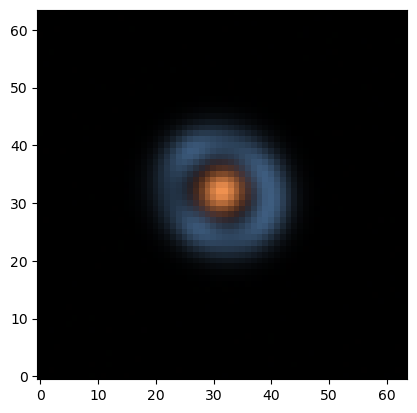

In [29]:

# we define a time variable function in magnitude space
numpix = 64
def var_func(time, band): #band either desg, desi, desr
    obs = Table({'time': [time],
             'band': [band],          #filters we are observing in 
             'gain': [1.],              #dw 
             'skynoise': [0],           #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [30.],               # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes 
             'zpsys':['ab']})           # ab magnitudes, units of zero point

    model = sncosmo.Model(source='salt2')
    params = {'z': z_source, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}  
    
    lcs = sncosmo.realize_lcs(obs, model, [params])
    flux_values = np.array(lcs[0]['flux'])
    zero_points = np.array(obs['zp'])
    magnitude = zero_points - 2.5 * np.log10(flux_values)
    return magnitude

var_func_g = lambda t: var_func(t, 'desg')
var_func_r = lambda t: var_func(t, 'desr')
var_func_i = lambda t: var_func(t, 'desi')


z_lens = 0.5
z_source = 0.9
kwargs_model_time_var = {'lens_model_list': ['EPL', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],  # list of extended source models to be used
                         'z_lens': z_lens, 'z_source': z_source
               }

from lenstronomy.SimulationAPI.point_source_variability import PointSourceVariability
ps_var_g = PointSourceVariability(source_x, source_y, var_func_g, numpix, kwargs_g_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=None)

ps_var_r = PointSourceVariability(source_x, source_y, var_func_r, numpix, kwargs_r_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_r, kwargs_lens_light_mag_r, kwargs_ps_mag=None)

ps_var_i = PointSourceVariability(source_x, source_y, var_func_i, numpix, kwargs_i_band, kwargs_model_time_var, kwargs_numerics,
                 kwargs_lens, kwargs_source_mag_i, kwargs_lens_light_mag_i, kwargs_ps_mag=None)

# these are the time delays of the multiple images (relative to the first appearing)
print(ps_var_g.delays)

# time = 10  # chose a time stamp of the image
time = 56176.19

image_g = ps_var_g.image_time(time=time)
image_g += sim_g.noise_for_model(model=image_g)

image_r = ps_var_r.image_time(time=time)
image_r += sim_r.noise_for_model(model=image_r)

image_i = ps_var_i.image_time(time=time)
image_i += sim_i.noise_for_model(model=image_i)


# plt.matshow(np.log10(image_g), origin='lower')
# plt.show()

img = np.zeros((image_g.shape[0], image_g.shape[1], 3), dtype=float)
img[:,:,0] = plot_util.sqrt(image_g, scale_min=0, scale_max=10000)
img[:,:,1] = plot_util.sqrt(image_r, scale_min=0, scale_max=10000)
img[:,:,2] = plot_util.sqrt(image_i, scale_min=0, scale_max=10000)

plt.clf()
plt.imshow(img, aspect='equal', origin='lower')
plt.show()

In [26]:
def var_func(time, band): #band either desg, desi, desr
    obs = Table({'time': [time],
             'band': [band],          #filters we are observing in 
             'gain': [1.],              #dw 
             'skynoise': [0],           #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [30.],               # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes 
             'zpsys':['ab']})           # ab magnitudes, units of zero point

    model = sncosmo.Model(source='salt2')
    params = {'z': z_source, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}  
    
    lcs = sncosmo.realize_lcs(obs, model, [params])
    flux_values = np.array(lcs[0]['flux'])
    zero_points = np.array(obs['zp'])
    magnitude = zero_points - 2.5 * np.log10(flux_values)
    return magnitude

var_func_g = lambda t: var_func(t, 'desg')
var_func_r = lambda t: var_func(t, 'desr')
var_func_i = lambda t: var_func(t, 'desi')


z_lens = 0.5
z_source = 0.9
time = 56176.19

print(var_func_g(time))
print(var_func_r(time))
print(var_func_i(time))

[27.68226578]
[24.59703872]
[23.86239917]
